In [2]:
import sys
from matplotlib import pyplot as plt
from sklift.metrics import uplift_at_k
import seaborn as sns
import numpy as np
import pandas as pd
import joblib
# install uplift library scikit-uplift and other libraries
#!{sys.executable} -m pip install scikit-uplift dill catboost

# %config InlineBackend.figure_format = 'svg'
# %matplotlib inline

## Load Dataset

We are going to use a Hillstrom dataset from the MineThatData [hosted](https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html) in march 2008 by the president of this company Kevin Hillstrom.

MineThatData is a consulting company that helps CEO understand the complex relationship between Customers, Advertising, Products, Brands, and Channels.

## Data description

Dataset can be loaded from sklift.datasets module using fetch_hillstrom function.

Read more about dataset in the [api docs](https://www.uplift-modeling.com/en/latest/api/datasets/fetch_hillstrom.html).

This dataset contains 64,000 customers who last purchased within twelve months. The customers were involved in an e-mail test

**Major columns**

- **visit** (binary): target. 1/0 indicator, 1 = Customer visited website in the following two weeks.

- **conversion** (binary): target. 1/0 indicator, 1 = Customer purchased merchandise in the following two weeks.

- **spend** (float): target. Actual dollars spent in the following two weeks.

- **segment** (str): treatment. The e-mail campaign the customer received

Read more in the [docs](https://www.uplift-modeling.com/en/latest/api/datasets/fetch_hillstrom.html#hillstrom)

In [16]:
from sklift.datasets import fetch_hillstrom

# returns sklearn Bunch object
# with data, target, treatment keys
# data features (pd.DataFrame), target (pd.Series), treatment (pd.Series) values
dataset = fetch_hillstrom(target_col='all')
joblib.dump(dataset, "data/hillstrom.joblib")

['data/hillstrom.joblib']

In [18]:
dataset.target

,visit,conversion,spend
0,0,0,0.0
1,0,0,0.0
2,0,0,0.0
3,0,0,0.0
4,0,0,0.0
...,...,...,...
63995,0,0,0.0
63996,0,0,0.0
63997,0,0,0.0
63998,0,0,0.0


In [17]:
dataset.target_name

['visit', 'conversion', 'spend']

In [7]:
dataset.keys()

dict_keys(['data', 'target', 'treatment', 'DESCR', 'feature_names', 'target_name', 'treatment_name'])

In [56]:
dataset = joblib.load("data/hillstrom.joblib")

In [57]:
print(f"Dataset type: {type(dataset)}\n")
print(f"Dataset features shape: {dataset.data.shape}")
print(f"Dataset target shape: {dataset.target.shape}")
print(f"Dataset treatment shape: {dataset.treatment.shape}")

Dataset type: <class 'sklearn.utils._bunch.Bunch'>

Dataset features shape: (64000, 8)
Dataset target shape: (64000,)
Dataset treatment shape: (64000,)


## EDA

In [58]:
pd.concat([dataset.data.head(), dataset.data.tail()])

,recency,history_segment,history,mens,womens,zip_code,newbie,channel
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone
63998,1,5) $500 - $750,552.94,1,0,Surburban,1,Multichannel
63999,1,4) $350 - $500,472.82,0,1,Surburban,0,Web


In [59]:
#info about types and null cells in dataset
dataset.data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  object 
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  object 
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 3.9+ MB


There is no missing data in the cells!

# Categorical data

In [60]:
cat_features = ['channel', 'zip_code', 'history_segment', 'newbie']

In [61]:
dataset.data.channel.unique()

array(['Phone', 'Web', 'Multichannel'], dtype=object)

In [62]:
dataset.data.zip_code.unique()

array(['Surburban', 'Rural', 'Urban'], dtype=object)

In [63]:
dataset.data.history_segment.unique()

array(['2) $100 - $200', '3) $200 - $350', '5) $500 - $750',
       '1) $0 - $100', '6) $750 - $1,000', '4) $350 - $500',
       '7) $1,000 +'], dtype=object)

**Zip code**

<Axes: xlabel='zip_code'>

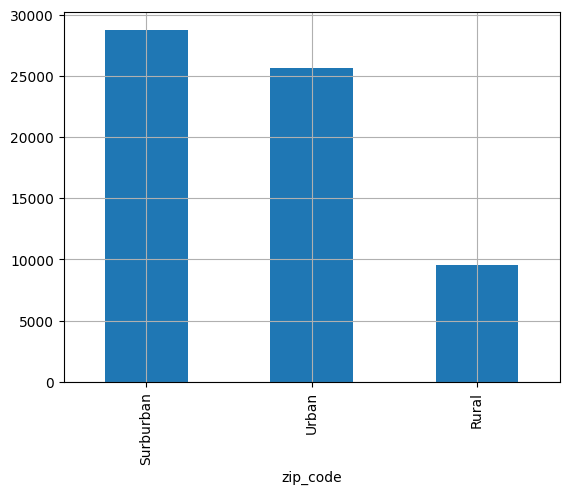

In [64]:
dataset.data.zip_code.value_counts().plot(kind = 'bar', grid=True)

**Channel**

<Axes: xlabel='channel'>

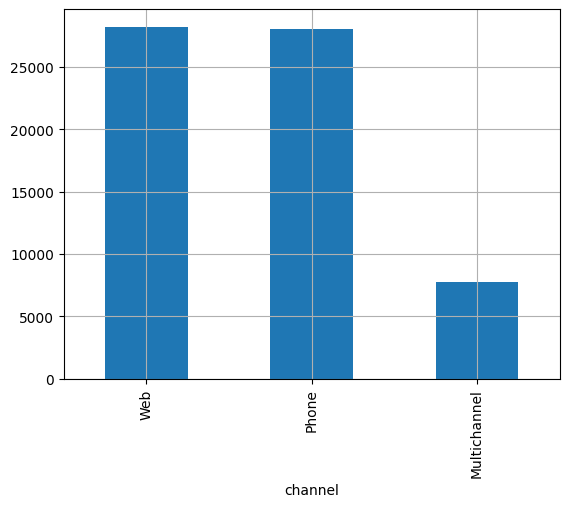

In [65]:
dataset.data.channel.value_counts().plot(kind = 'bar', grid=True)

**History segment**

<Axes: xlabel='history_segment'>

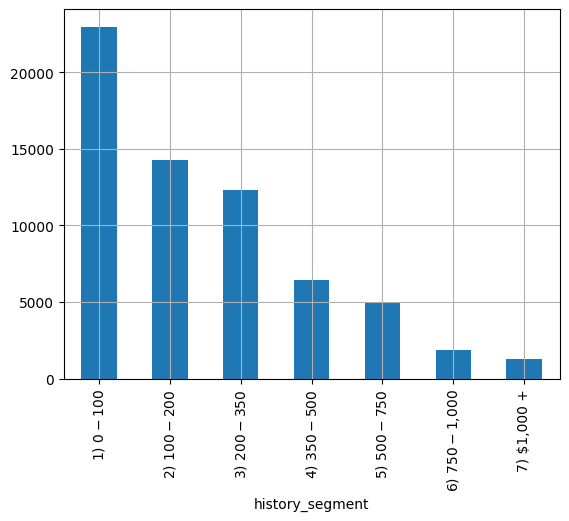

In [66]:
dataset.data.history_segment.value_counts().plot(kind = 'bar', grid=True)

In [67]:
#As option I propose to apply following function for transformation data in column "historic_segment"
def historic_segment_transform(dataset):
    for payment in dataset.data['history_segment'].unique():
        if payment =='1) $0 - $100':
            dataset.data.loc[dataset.data['history_segment'] == payment, 'history_segment'] = 50
        elif payment =='2) $100 - $200':
            dataset.data.loc[dataset.data['history_segment'] == payment, 'history_segment'] = 150
        elif payment =='3) $200 - $350':
            dataset.data.loc[dataset.data['history_segment'] == payment, 'history_segment'] = 275
        elif payment =='4) $350 - $500':
            dataset.data.loc[dataset.data['history_segment'] == payment, 'history_segment'] = 425
        elif payment =='5) $500 - $750':
            dataset.data.loc[dataset.data['history_segment'] == payment, 'history_segment'] = 575
        elif payment =='5) $750 - $1000':
            dataset.data.loc[dataset.data['history_segment'] == payment, 'history_segment'] = 825
        else:
            dataset.data.loc[dataset.data['history_segment'] == payment, 'history_segment'] = 1000
    return dataset.data.history_segment

In [68]:
dataset.data.history_segment.value_counts()

history_segment
1) $0 - $100        22970
2) $100 - $200      14254
3) $200 - $350      12289
4) $350 - $500       6409
5) $500 - $750       4911
6) $750 - $1,000     1859
7) $1,000 +          1308
Name: count, dtype: int64

<Axes: xlabel='history_segment'>

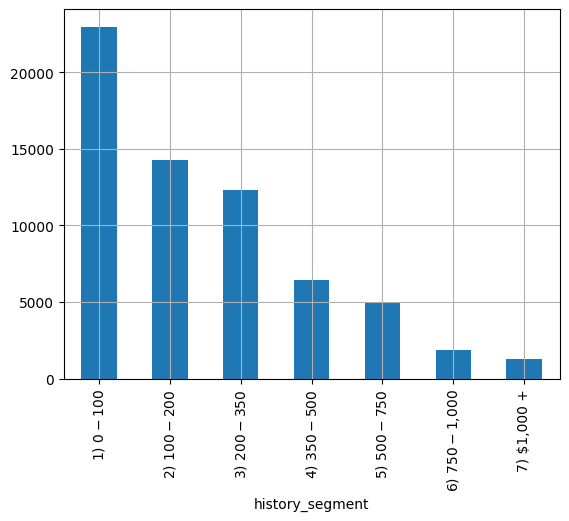

In [69]:
dataset.data.history_segment.value_counts().plot(kind = 'bar', grid=True)

In [70]:
#It's better to proceed from categorical to numeric data
# For example, we could replace 0-100 on average value 50

<Axes: xlabel='womens'>

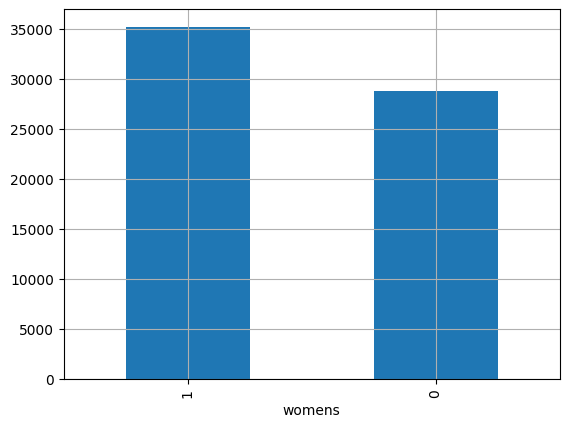

In [71]:
dataset.data.womens.value_counts().plot(kind = 'bar', grid=True)

<Axes: xlabel='mens'>

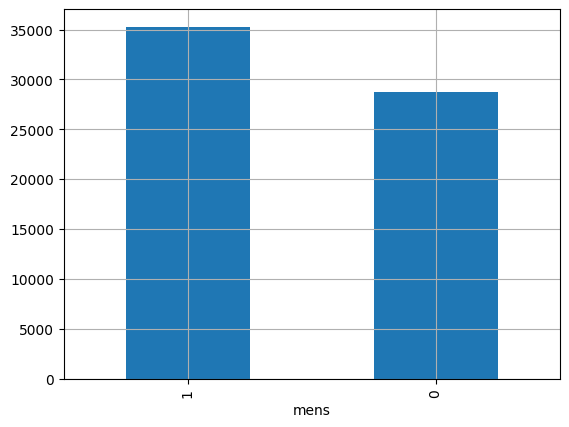

In [72]:
dataset.data.mens.value_counts().plot(kind = 'bar', grid=True)

In [73]:
dataset.data.womens.value_counts()

womens
1    35182
0    28818
Name: count, dtype: int64

In [74]:
dataset.data.groupby('womens').size()/dataset.data['womens'].count()*100

womens
0    45.028125
1    54.971875
dtype: float64

In [75]:
#55% - womens purchases
#44% - mens purchases

In [76]:
dataset.data.mens.value_counts()

mens
1    35266
0    28734
Name: count, dtype: int64

In [77]:
dataset.data.groupby('mens').size()/dataset.data['mens'].count()*100

mens
0    44.896875
1    55.103125
dtype: float64

In [78]:
#55% - mens purchases
#44% - womens purchases

In [79]:
dataset.data

,recency,history_segment,history,mens,womens,zip_code,newbie,channel
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web
...,...,...,...,...,...,...,...,...
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone
63998,1,5) $500 - $750,552.94,1,0,Surburban,1,Multichannel


In [80]:
# mapping = {
#     '1) $0 - $100': 50,
#     '2) $100 - $200': 150,
#     '3) $200 - $350': 275,
#     '4) $350 - $500': 425,
#     '5) $500 - $750': 625,
#     '6) $750 - $1000': 875
# }

# dataset.data["history_segment"] = (
#     dataset.data["history_segment"]
#     .map(mapping)
#     .fillna(1000)
# )

In [81]:
dataset

{'data':        recency history_segment  history  mens  womens   zip_code  newbie  \
 0           10  2) $100 - $200   142.44     1       0  Surburban       0   
 1            6  3) $200 - $350   329.08     1       1      Rural       1   
 2            7  2) $100 - $200   180.65     0       1  Surburban       1   
 3            9  5) $500 - $750   675.83     1       0      Rural       1   
 4            2    1) $0 - $100    45.34     1       0      Urban       0   
 ...        ...             ...      ...   ...     ...        ...     ...   
 63995       10  2) $100 - $200   105.54     1       0      Urban       0   
 63996        5    1) $0 - $100    38.91     0       1      Urban       1   
 63997        6    1) $0 - $100    29.99     1       0      Urban       1   
 63998        1  5) $500 - $750   552.94     1       0  Surburban       1   
 63999        1  4) $350 - $500   472.82     0       1  Surburban       0   
 
             channel  
 0             Phone  
 1               Web

<Axes: >

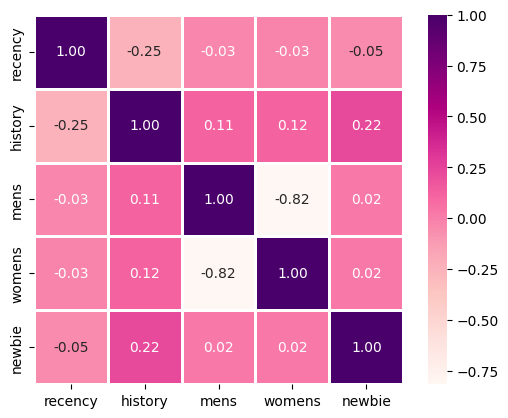

In [82]:
numeric_df = dataset.data.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr().round(3),
    annot=True,
    square=True,
    linewidths=.75,
    cmap='RdPu',
    fmt='.2f',
    annot_kws={"size": 10}
)

In [83]:
# womens and mens are in inverse correlation. I propose to make 1 column "gender" and merge.

In [84]:
# As we can see, there is high correlation between 'history_segment' and 'history'. Could we merge it also and transform columns to numeric data?

# Numeric data

<Axes: >

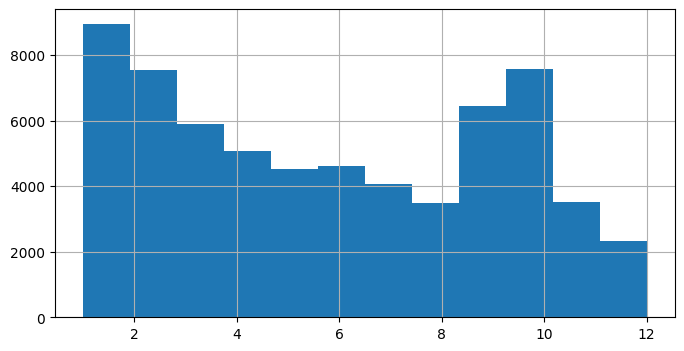

In [85]:
dataset.data.loc[:, 'recency'].hist(figsize=(8, 4), bins=12, grid=True)

In [86]:
dataset.data.history.value_counts()

history
29.99     7947
81.20        9
53.79        9
47.03        8
142.94       8
          ... 
455.24       1
241.42       1
642.90       1
211.45       1
675.07       1
Name: count, Length: 34833, dtype: int64

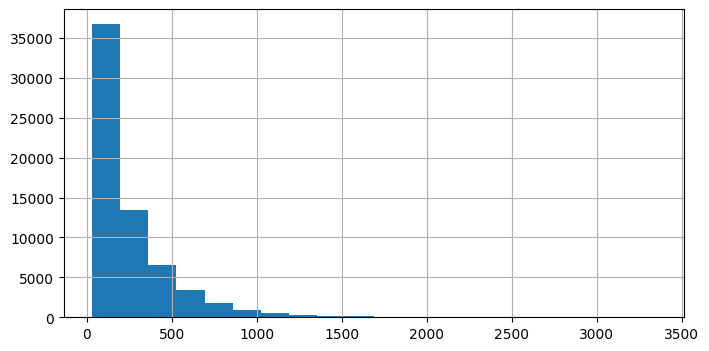

In [87]:
dataset.data.loc[:, 'history'].hist(figsize=(8, 4), bins=20, grid=True);

# Target data

In [88]:
#dataset_segment
dataset.treatment.value_counts()

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

In [89]:
dataset.treatment.unique()

array(['Womens E-Mail', 'No E-Mail', 'Mens E-Mail'], dtype=object)

<Axes: xlabel='segment'>

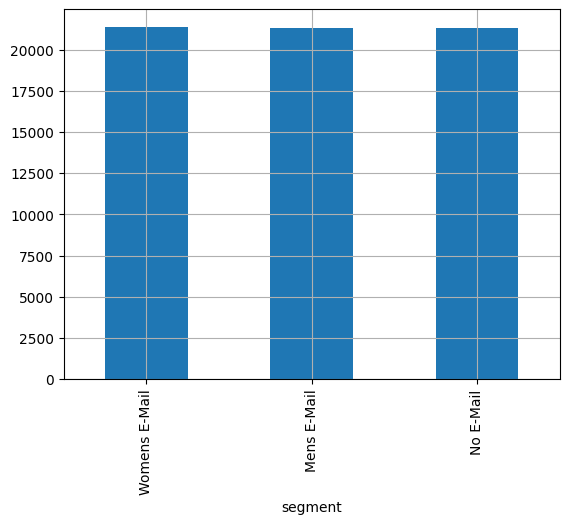

In [90]:
dataset.treatment.value_counts().plot(kind = 'bar', grid = 'True')

In [91]:
#dataset_visit
dataset.target.head()

0    0
1    0
2    0
3    0
4    0
Name: visit, dtype: int64

<Axes: xlabel='visit'>

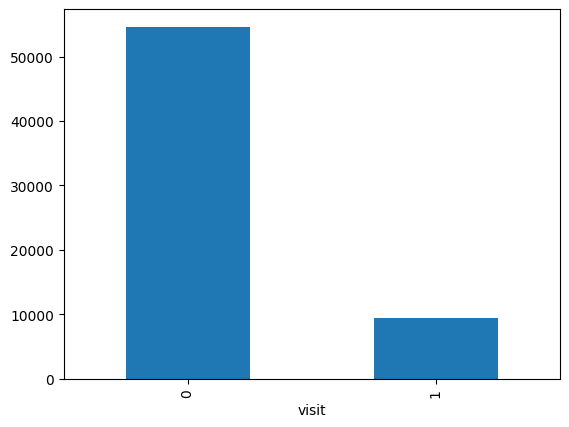

In [92]:
dataset.target.value_counts().plot(kind = 'bar')

In [93]:
#Target is disbalanced

In [94]:
import pandas as pd

pd.crosstab(dataset.treatment, dataset.target, normalize='index')

visit,0,1
segment,,
Mens E-Mail,0.817243,0.182757
No E-Mail,0.893833,0.106167
Womens E-Mail,0.848600,0.151400


In [95]:
dataset.target.unique()

array([0, 1])

Text(0.5, 1.0, 'Treatment & Target')

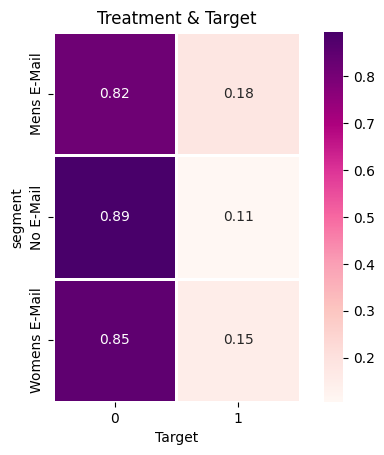

In [96]:
crosstab = pd.crosstab(dataset.treatment, dataset.target, normalize='index')

sns.heatmap(crosstab, annot=True, fmt=".2f", linewidths=1, square = True, cmap = 'RdPu')
plt.xlabel('Target')
plt.title("Treatment & Target")

In [97]:
#Let's consider two cases:
#1) Womens E-mail - No E-mail
#2) Mens E-mail - No E-mail

## Womens E-mail - No E-mail

In [98]:
# make treatment binary
treat_dict_womens = {
            'Womens E-Mail': 1,
            'No E-Mail': 0,
            'Mens E-Mail': 0
            }
dataset.treatment_womens = dataset.treatment.map(treat_dict_womens)

<Axes: xlabel='segment'>

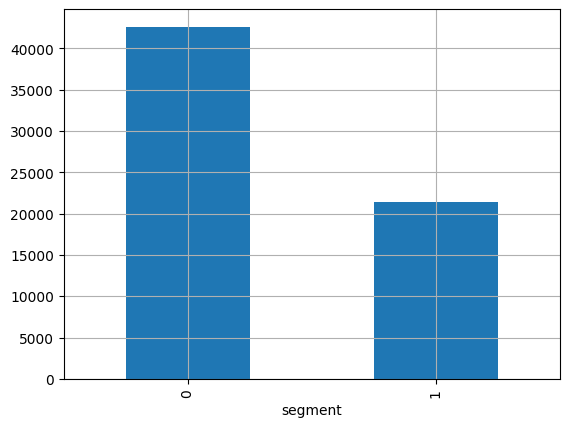

In [99]:
dataset.treatment_womens.value_counts().plot(kind = 'bar', grid = 'True')

In [100]:
stratify_cols = pd.concat([dataset.treatment_womens, dataset.target], axis=1)

In [101]:
stratify_cols.head(5)

,segment,visit
0,1,0
1,0,0
2,1,0
3,0,0
4,1,0


## Modelling

In [132]:
from sklearn.model_selection import train_test_split

stratify_cols = pd.concat([dataset.treatment_womens, dataset.target], axis=1)

X_train, X_val, trmnt_train, trmnt_val, y_train, y_val = train_test_split(
    dataset.data,
    dataset.treatment_womens,
    dataset.target,
    stratify=stratify_cols,
    test_size=0.3,
    random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

Train shape: (44800, 8)
Validation shape: (19200, 8)


In [133]:
from sklift.models import ClassTransformation
from catboost import CatBoostClassifier

estimator = CatBoostClassifier(verbose=100,
                               cat_features=['womens', 'mens','channel', 'zip_code', 'history_segment', 'newbie'],
                               random_state=42,
                               thread_count=1
                              )

ct_model = ClassTransformation(estimator=estimator)

In [134]:
ct_model.fit(
    X=X_train,
    y=y_train,
    treatment=trmnt_train
)

Learning rate set to 0.052243
0:	learn: 0.6900041	total: 63.8ms	remaining: 1m 3s
100:	learn: 0.6610229	total: 5.21s	remaining: 46.4s
200:	learn: 0.6594380	total: 11.1s	remaining: 44s
300:	learn: 0.6569047	total: 17.2s	remaining: 39.8s
400:	learn: 0.6546442	total: 23.5s	remaining: 35.1s
500:	learn: 0.6523825	total: 29.8s	remaining: 29.7s
600:	learn: 0.6504138	total: 36.1s	remaining: 24s
700:	learn: 0.6482230	total: 42.3s	remaining: 18.1s
800:	learn: 0.6463583	total: 48.7s	remaining: 12.1s
900:	learn: 0.6445439	total: 54.9s	remaining: 6.04s
999:	learn: 0.6427664	total: 1m 1s	remaining: 0us


,estimator,"CatBoostClass..., verbose=100)"


In [105]:
#in progress with multiclassclassifier for Catboost.

In [135]:
from sklift.metrics import uplift_at_k

In [136]:
uplift_predictions = ct_model.predict(X_val)

In [137]:
# k = 10%
k = 0.1

# strategy='overall' sort by uplift treatment and control together
uplift_overall = uplift_at_k(y_val, uplift_predictions, trmnt_val, strategy='overall', k=k)

# strategy='by_group' sort by uplift treatment and control separately
uplift_bygroup = uplift_at_k(y_val, uplift_predictions, trmnt_val, strategy='by_group', k=k)


print(f"uplift@{k * 100:.0f}%: {uplift_overall:.4f} (sort groups by uplift together)")
print(f"uplift@{k * 100:.0f}%: {uplift_bygroup:.4f} (sort groups by uplift separately)")

uplift@10%: 0.0314 (sort groups by uplift together)
uplift@10%: 0.0333 (sort groups by uplift separately)


In [138]:
from sklift.metrics import qini_auc_score

# 1. Get predictions for both sets
# Remember: ct_model_mens is the one you already trained on X_train
train_preds = ct_model.predict(X_train)
val_preds = ct_model.predict(X_val)

# 2. Calculate Qini scores
qini_train = qini_auc_score(
    y_true=y_train, 
    uplift=train_preds, 
    treatment=trmnt_train
)

qini_val = qini_auc_score(
    y_true=y_val, 
    uplift=val_preds, 
    treatment=trmnt_val
)

print(f"Qini Score (Train): {qini_train:.4f}")
print(f"Qini Score (Validation): {qini_val:.4f}")

Qini Score (Train): 0.1214
Qini Score (Validation): 0.0296


## Mens E-mail - No E-mail

In [109]:
treat_dict_mens = {
            'Mens E-Mail': 1,
            'No E-Mail': 0,
            'Womens E-Mail': 0
            }
dataset.treatment_mens = dataset.treatment.map(treat_dict_mens)

In [110]:
dataset.treatment_mens = dataset.treatment.map(treat_dict_mens)

<Axes: xlabel='segment'>

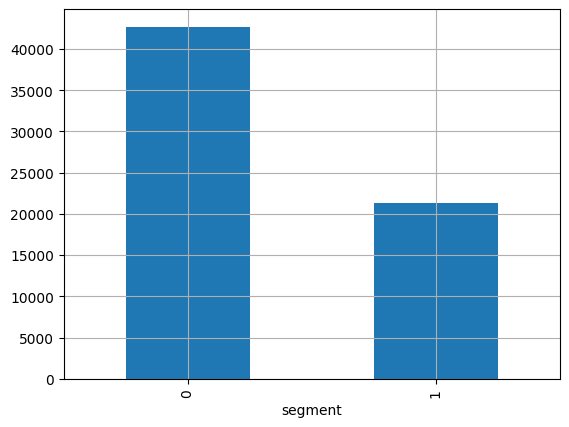

In [111]:
dataset.treatment_mens.value_counts().plot(kind = 'bar', grid = 'True')

In [112]:
stratify_cols = pd.concat([dataset.treatment_mens, dataset.target], axis=1)

In [113]:
from sklearn.model_selection import train_test_split

stratify_cols = pd.concat([dataset.treatment_mens, dataset.target], axis=1)

X_train, X_val, trmnt_train, trmnt_val, y_train, y_val = train_test_split(
    dataset.data,
    dataset.treatment_mens,
    dataset.target,
    stratify=stratify_cols,
    test_size=0.3,
    random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

Train shape: (44800, 8)
Validation shape: (19200, 8)


In [122]:
from sklift.models import ClassTransformation
from catboost import CatBoostClassifier

estimator = CatBoostClassifier(verbose=100,
                               cat_features=['womens', 'mens','channel', 'zip_code', 'history_segment', 'newbie'],
                               random_state=42,
                               early_stopping_rounds=50,
                               thread_count=1
                              )

ct_model_mens = ClassTransformation(estimator=estimator)

In [123]:
ct_model_mens.fit(
    X=X_train,
    y=y_train,
    treatment=trmnt_train
)

Learning rate set to 0.052243
0:	learn: 0.6888651	total: 82.3ms	remaining: 1m 22s
100:	learn: 0.6507044	total: 5.94s	remaining: 52.9s
200:	learn: 0.6493217	total: 11.3s	remaining: 44.9s
300:	learn: 0.6466936	total: 17.9s	remaining: 41.7s
400:	learn: 0.6437030	total: 25.2s	remaining: 37.6s
500:	learn: 0.6413201	total: 32.2s	remaining: 32s
600:	learn: 0.6390236	total: 38.6s	remaining: 25.6s
700:	learn: 0.6366626	total: 45.1s	remaining: 19.2s
800:	learn: 0.6342987	total: 51.7s	remaining: 12.8s
900:	learn: 0.6322623	total: 58.3s	remaining: 6.41s
999:	learn: 0.6303895	total: 1m 5s	remaining: 0us


,estimator,"CatBoostClass..., verbose=100)"


In [124]:
uplift_predictions_mens = ct_model_mens.predict(X_val)

In [119]:
# k = 10%
k = 0.1

# strategy='overall' sort by uplift treatment and control together
uplift_overall_mens = uplift_at_k(y_val, uplift_predictions_mens, trmnt_val, strategy='overall', k=k)

# strategy='by_group' sort by uplift treatment and control separately
uplift_bygroup_mens = uplift_at_k(y_val, uplift_predictions_mens, trmnt_val, strategy='by_group', k=k)


print(f"uplift@{k * 100:.0f}%: {uplift_overall_mens:.4f} (sort groups by uplift_mens together)")
print(f"uplift@{k * 100:.0f}%: {uplift_bygroup_mens:.4f} (sort groups by uplift_mens separately)")

uplift@10%: 0.0610 (sort groups by uplift_mens together)
uplift@10%: 0.0604 (sort groups by uplift_mens separately)


In [120]:
from sklift.metrics import uplift_at_k, qini_auc_score

# 1. Calculate Qini Score
qini_score = qini_auc_score(y_true=y_val, uplift=uplift_predictions_mens, treatment=trmnt_val)
print(f"Qini: {qini_score}")


Qini: 0.011997738549748515


In [127]:
from sklift.metrics import qini_auc_score

# 1. Get predictions for both sets
# Remember: ct_model_mens is the one you already trained on X_train
train_preds = ct_model_mens.predict(X_train)
val_preds = ct_model_mens.predict(X_val)

# 2. Calculate Qini scores
qini_train = qini_auc_score(
    y_true=y_train, 
    uplift=train_preds, 
    treatment=trmnt_train
)

qini_val = qini_auc_score(
    y_true=y_val, 
    uplift=val_preds, 
    treatment=trmnt_val
)

print(f"Qini Score (Train): {qini_train:.4f}")
print(f"Qini Score (Validation): {qini_val:.4f}")

Qini Score (Train): 0.1144
Qini Score (Validation): 0.0120


### Lightgbm

In [130]:
import lightgbm as lgb
from sklift.models import ClassTransformation

# 1. Preprocessing for LightGBM
# LightGBM requires categorical features to be 'category' dtype or encoded
cat_cols = ['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie']
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')

# 2. Configure LightGBM Estimator
# We use LGBMClassifier here
lgbm_estimator = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,          # Important: lower this to prevent overfitting
    min_data_in_leaf=50,    # Important: prevents memorizing tiny groups
    random_state=42,
    n_jobs=1,
    verbose=-1
)

# 3. Fit
ct_model_lgbm = ClassTransformation(estimator=lgbm_estimator)

ct_model_lgbm.fit(
    X=X_train,
    y=y_train,
    treatment=trmnt_train
)

# 4. Predict
lgbm_preds = ct_model_lgbm.predict(X_val)

In [131]:

# 3. Predict for both sets
train_preds = ct_model_lgbm.predict(X_train)
val_preds = ct_model_lgbm.predict(X_val)

# 4. Calculate Qini
qini_train = qini_auc_score(y_true=y_train, uplift=train_preds, treatment=trmnt_train)
qini_val = qini_auc_score(y_true=y_val, uplift=val_preds, treatment=trmnt_val)

print(f"Qini Score (Train): {qini_train:.4f}")
print(f"Qini Score (Validation): {qini_val:.4f}")

# Optional: Check the gap
print(f"Gap: {qini_train - qini_val:.4f}")

Qini Score (Train): 0.2704
Qini Score (Validation): 0.0007
Gap: 0.2697
